# Does the gaussian fit actually improve on celldetect?

`gaussian_detect` exists to refine `celldetect`'s cell-based centroid with a proper 2D
Gaussian fit to the surrounding events. This notebook checks whether that refinement
is actually worth it, against the one ground truth available: `dr`, the angular
separation to a matched reference catalog counterpart (RFC/Gaia/ICRF/etc., precise to
much better than a Chandra centroid).

**The comparison is paired, not two separate populations**: for every (obsid, x_id)
whose `celldetect` row and `gaussian_detect` row both matched the *same* catalog
counterpart (`c_id`), this compares `dr` computed from each position. Both sides come
from the exact same underlying source, so the only thing that differs is which
position estimate was used.

**Contamination is excluded from both sides, not reprocessed away.** A source flagged
`grating_arm` or `acis_streak` -- on *either* the celldetect row or the gaussian_detect
row -- has no valid position to begin with, so a `dr` computed from it is not a fair
test of which method centroids better. Excluding these is not the same as the new
prefilter added in this branch: that prefilter stops a fit from being *attempted* on a
contaminated celldetect seed; this is about not scoring a comparison where one or both
sides are already known-bad, in a database that has not been reprocessed with that
prefilter yet.

**Branch under review:** `stack/04-detection-methods`
**Fix location:** `astromon/observation.py` (`gaussian_detect`, `_fit_gaussian_sources`)


In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_DIR = "/Users/jean/git/astromon_project"
BRANCH = "stack/04-detection-methods"
PARENT_BRANCH = "stack/03-public-archive-access"

# Import astromon from REPO_DIR explicitly, not whatever's ambiently importable --
# astromon is also pip-installed in this environment, separate from any git
# checkout. REPO_DIR must have `stack/04-detection-methods` (or a branch built on
# it) checked out for this to demonstrate the fix.
sys.path.insert(0, REPO_DIR)
os.environ.setdefault("SKA", "/Users/jean/ska")
os.environ.setdefault("ASTROMON_FILE", "/Volumes/Black/data/astromon/astromon.h5")

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
from astropy import coordinates as coords
from astropy import table
from astropy.io import fits
from chandra_aca.transform import radec_to_yagzag
from matplotlib.colors import LogNorm
from Quaternion import Quat

from astromon import db, observation, utils

print("astromon imported from:", utils.__file__)

BASE_WORK_DIR = "/Volumes/Black/data/astromon/work"

# Not portable -- this machine's production database and cache of archive
# products, matching this repo's other one-off review notebooks.


astromon imported from: /Users/jean/git/astromon_project/astromon/utils.py


## 1. What `stack/04-detection-methods` actually changes

Pulling the live diff against its own parent branch (rather than `master`, which would also pull in 01-03's unrelated changes) so this stays accurate if the branch moves.


In [2]:
diff_stat = subprocess.run(
    ["git", "diff", f"{PARENT_BRANCH}...{BRANCH}", "--stat", "--",
     "astromon/observation.py", "astromon/source_detection.py"],
    cwd=REPO_DIR, capture_output=True, text=True, check=True,
).stdout
print(diff_stat)


 astromon/observation.py      | 339 +++++++++++++++++++++++++++++++++++++++++--
 astromon/source_detection.py |  87 ++++++++++-
 2 files changed, 410 insertions(+), 16 deletions(-)



`gaussian_detect` itself already exists in `master`; this branch refactors it
(extracting `_fit_gaussian_sources`, shared with the new `peak_gaussian_detect`)
and adds `concentration_ratio`, a per-source point/extended discriminator computed
from the same fit. This notebook validates `gaussian_detect`'s pre-existing
centroid-refinement behavior -- does it land closer to the truth than celldetect's
own position -- using `concentration_ratio` as a moderating variable, against the
real, whole-database cross-match history rather than a single case. The refactor
itself does not change the fit math for a source that still gets fit -- but this
branch also has `gaussian_detect` skip celldetect seeds that are crowded, on a
grating arm, or affected by an ACIS streak (sections skipped in this notebook);
for surviving sources, this notebook's numbers reflect `gaussian_detect`'s
pre-existing centroid-refinement behavior, not something newly introduced here.


## 2. The paired comparison, across the whole database

Every (obsid, x_id, c_id) triple with a `celldetect` row and a `gaussian_detect` row matched to the same catalog counterpart.


In [3]:
xray = db.get_table("astromon_xray_src")
xc = db.get_table("astromon_xcorr")

cd_xray = xray[xray["detect_method"] == "celldetect"]
gd_xray = xray[xray["detect_method"] == "gaussian_detect"]

cd_pos = {
    (int(o), int(i)): (float(ra), float(dec), float(s))
    for o, i, ra, dec, s in zip(
        cd_xray["obsid"], cd_xray["id"], cd_xray["ra"], cd_xray["dec"], cd_xray["snr"], strict=True
    )
}
gd_pos = {
    (int(o), int(i)): (float(ra), float(dec))
    for o, i, ra, dec in zip(gd_xray["obsid"], gd_xray["id"], gd_xray["ra"], gd_xray["dec"], strict=True)
}
cd_flags = {
    (int(o), int(i)): (bool(a), bool(g))
    for o, i, a, g in zip(
        cd_xray["obsid"], cd_xray["id"], cd_xray["acis_streak"], cd_xray["grating_arm"], strict=True
    )
}
gd_flags = {
    (int(o), int(i)): (bool(a), bool(g))
    for o, i, a, g in zip(
        gd_xray["obsid"], gd_xray["id"], gd_xray["acis_streak"], gd_xray["grating_arm"], strict=True
    )
}
gd_concentration = {
    (int(o), int(i)): float(cr)
    for o, i, cr in zip(gd_xray["obsid"], gd_xray["id"], gd_xray["concentration_ratio"], strict=True)
}

cd_xc = xc[xc["detect_method"] == "celldetect"]
gd_xc = xc[xc["detect_method"] == "gaussian_detect"]


def dedupe(t):
    """One dr per (obsid, x_id, c_id) -- the same triple can repeat across
    select_names with the same dr; keep the first."""
    keys = list(zip(t["obsid"].tolist(), t["x_id"].tolist(), t["c_id"].tolist(), strict=True))
    seen = {}
    for key, dr in zip(keys, t["dr"], strict=True):
        seen.setdefault(key, float(dr))
    return seen


cd_map, gd_map = dedupe(cd_xc), dedupe(gd_xc)
common = sorted(set(cd_map) & set(gd_map))
print(f"celldetect matches: {len(cd_map):,}  gaussian_detect matches: {len(gd_map):,}")
print(f"matched to the SAME catalog counterpart under both: {len(common):,}")


celldetect matches: 22,435  gaussian_detect matches: 22,144
matched to the SAME catalog counterpart under both: 22,127


In [4]:
def is_clean(obsid, x_id):
    cs, ca = cd_flags.get((obsid, x_id), (True, True))  # missing -> unknown, treat as unclean
    gs, ga = gd_flags.get((obsid, x_id), (True, True))
    return not (cs or ca or gs or ga)


pairs = []  # (sep_arcsec, obsid, x_id, c_id, cd_snr, gd_concentration_ratio)
n_excluded = 0
for obsid, x_id, c_id in common:
    if (obsid, x_id) not in cd_pos or (obsid, x_id) not in gd_pos:
        continue
    if not is_clean(obsid, x_id):
        n_excluded += 1
        continue
    ra1, dec1, snr = cd_pos[(obsid, x_id)]
    ra2, dec2 = gd_pos[(obsid, x_id)]
    sep = coords.SkyCoord(ra1, dec1, unit="deg").separation(coords.SkyCoord(ra2, dec2, unit="deg")).arcsec
    cr = gd_concentration.get((obsid, x_id), float("nan"))
    pairs.append((sep, obsid, x_id, c_id, snr, cr))

print(f"excluded (celldetect or gaussian_detect flagged grating_arm/acis_streak): "
      f"{n_excluded:,} ({n_excluded / len(common):.1%})")
print(f"clean pairs: {len(pairs):,}")


excluded (celldetect or gaussian_detect flagged grating_arm/acis_streak): 21 (0.1%)
clean pairs: 22,106


## 3. Aggregate: does gaussian_detect win, and by how much?

`dr` is the raw separation to the catalog counterpart (`sqrt(dy**2 + dz**2)`, no
normalization by expected error or anything else) -- smaller is closer to the
counterpart, and is taken as the better position. "Wins"/"win rate" below just means:
for a given pair, whichever of `celldetect`'s or `gaussian_detect`'s `dr` is smaller.


In [5]:
dr_cd_all = np.array([cd_map[(o, i, c)] for _, o, i, c, _, _ in pairs])
dr_gd_all = np.array([gd_map[(o, i, c)] for _, o, i, c, _, _ in pairs])
win_rate_overall = int((dr_gd_all < dr_cd_all).sum()) / len(pairs)

print(f"median dr: celldetect={np.median(dr_cd_all):.4f}\"  gaussian_detect={np.median(dr_gd_all):.4f}\"")
print(f"mean dr:   celldetect={np.mean(dr_cd_all):.4f}\"  gaussian_detect={np.mean(dr_gd_all):.4f}\"")
print(f"gaussian_detect closer: {win_rate_overall:.1%} of {len(pairs):,} pairs")


median dr: celldetect=0.2857"  gaussian_detect=0.2767"
mean dr:   celldetect=0.3726"  gaussian_detect=0.3633"
gaussian_detect closer: 55.4% of 22,106 pairs


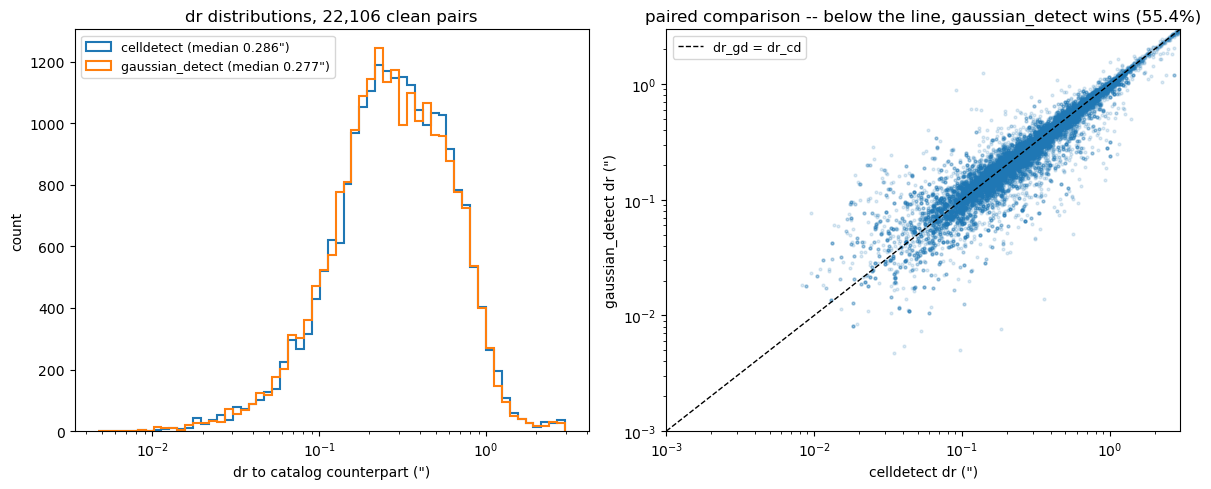

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
bins = np.logspace(np.log10(max(dr_cd_all.min(), dr_gd_all.min(), 1e-3)), np.log10(max(dr_cd_all.max(), dr_gd_all.max())), 60)
ax.hist(dr_cd_all, bins=bins, histtype="step", lw=1.5, label=f"celldetect (median {np.median(dr_cd_all):.3f}\")")
ax.hist(dr_gd_all, bins=bins, histtype="step", lw=1.5, label=f"gaussian_detect (median {np.median(dr_gd_all):.3f}\")")
ax.set_xscale("log")
ax.set_xlabel('dr to catalog counterpart (")')
ax.set_ylabel("count")
ax.set_title(f"dr distributions, {len(pairs):,} clean pairs")
ax.legend(fontsize=9)

ax = axes[1]
lo = max(min(dr_cd_all.min(), dr_gd_all.min()), 1e-3)
hi = max(dr_cd_all.max(), dr_gd_all.max())
ax.scatter(dr_cd_all, dr_gd_all, s=4, alpha=0.15, rasterized=True)
ax.plot([lo, hi], [lo, hi], color="k", lw=1, ls="--", label="dr_gd = dr_cd")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel('celldetect dr (")')
ax.set_ylabel('gaussian_detect dr (")')
ax.set_title(f"paired comparison -- below the line, gaussian_detect wins ({win_rate_overall:.1%})")
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()


Left: the two methods' `dr` distributions side by side -- gaussian_detect's is
shifted slightly left (smaller separations). Right: the same comparison paired
per-source -- each point is one (obsid, x_id) pair, plotted at (celldetect dr,
gaussian_detect dr); points below the diagonal are cases gaussian_detect wins.
The bulk sits near the diagonal (most pairs agree within noise), with the scatter
below the line visibly denser than above it.


A real but modest edge overall. Most of these pairs are cases where the two methods
land within noise of each other -- averaging over them dilutes whatever the fit
actually contributes. The next section separates "they agree" from "they don't."


## 4. A representative example: obsid 2177 (IC 4329A)


using cached filtered evt2: /Volumes/Black/data/astromon/work/obs02/2177/primary/2177_evt2_filtered.fits.gz


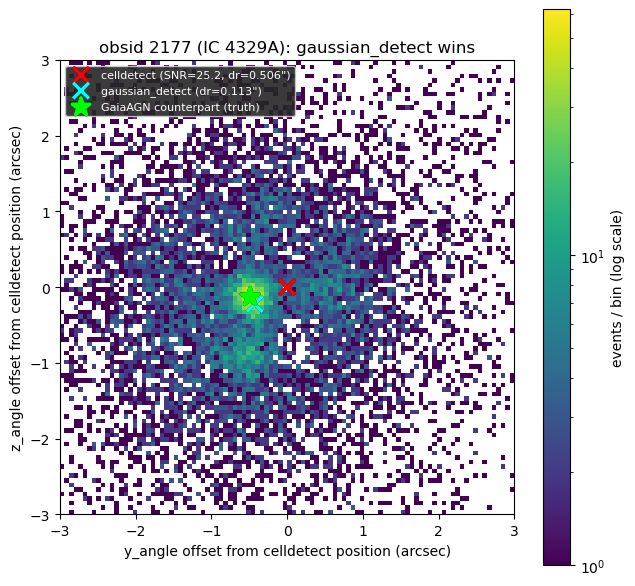

In [7]:
def resolve_filtered_evt2(obsid: int, base_work_dir: str) -> Path:
    """Return this obsid's filtered event file, downloading the raw evt2 (and
    reporting how to produce the filtered one) if nothing is cached."""
    workdir = Path(base_work_dir) / f"obs{obsid // 1000:02d}" / str(obsid)
    matches = sorted((workdir / "primary").glob("*_evt2_filtered.fits.gz"))
    if matches:
        print(f"using cached filtered evt2: {matches[0]}")
        return matches[0]

    raw_matches = sorted((workdir / "primary").glob("*_evt2.fits*"))
    if not raw_matches:
        print(f"no cached evt2 under {workdir} -- downloading from the public archive")
        obs = observation.Observation(obsid, workdir=base_work_dir, source="archive")
        obs.download(["evt2"])
        raw_matches = sorted((workdir / "primary").glob("*_evt2.fits*"))
    if not raw_matches:
        raise FileNotFoundError(f"obsid {obsid}: no evt2 file even after downloading")

    raise FileNotFoundError(
        f"{workdir}/primary has a raw evt2 ({raw_matches[0].name}) but no "
        f"*_evt2_filtered.fits.gz -- that filtering is a pipeline step (filter_events), "
        "not an archive download. To generate it:\n"
        f"  python -m astromon.observation {obsid} --workdir {base_work_dir} --data-source archive"
    )


def plot_example(obsid, x_id, c_id, window, title):
    """Plot event density with celldetect, gaussian_detect and the catalog
    counterpart marked, in a frame centred on the celldetect position."""
    outline = [pe.withStroke(linewidth=2.5, foreground="black")]

    cat = db.get_table("astromon_cat_src")
    cd_row = xray[(xray["obsid"] == obsid) & (xray["id"] == x_id) & (xray["detect_method"] == "celldetect")][0]
    gd_row = xray[(xray["obsid"] == obsid) & (xray["id"] == x_id) & (xray["detect_method"] == "gaussian_detect")][0]
    cat_row = cat[(cat["obsid"] == obsid) & (cat["id"] == c_id)][0]
    dr_cd = cd_map[(obsid, x_id, c_id)]
    dr_gd = gd_map[(obsid, x_id, c_id)]

    evt2 = resolve_filtered_evt2(obsid, BASE_WORK_DIR)
    obs = observation.Observation(obsid, workdir=BASE_WORK_DIR, source="archive", use_ciao=False)
    obspar = obs.get_obspar()
    att = Quat([obspar["ra_nom"], obspar["dec_nom"], obspar["roll_nom"]])

    events = table.Table.read(evt2, hdu=1)
    wcs = utils.get_wcs_from_fits_header(evt2, hdu=1)
    events["RA"], events["DEC"] = wcs.pixel_to_world_values(events["x"], events["y"])
    ey, ez = radec_to_yagzag(events["RA"], events["DEC"], att)
    ey, ez = np.asarray(ey), np.asarray(ez)

    origin_y, origin_z = radec_to_yagzag(float(cd_row["ra"]), float(cd_row["dec"]), att)
    gd_y, gd_z = np.array(radec_to_yagzag(float(gd_row["ra"]), float(gd_row["dec"]), att)) - [origin_y, origin_z]
    cat_y, cat_z = np.array(radec_to_yagzag(float(cat_row["ra"]), float(cat_row["dec"]), att)) - [origin_y, origin_z]

    near = (np.abs(ey - origin_y) < window) & (np.abs(ez - origin_z) < window)

    fig, ax = plt.subplots(figsize=(6.5, 6))
    h = ax.hist2d(ey[near] - origin_y, ez[near] - origin_z, bins=100,
                   range=[[-window, window], [-window, window]], cmap="viridis", norm=LogNorm(vmin=1))
    plt.colorbar(h[3], ax=ax, label="events / bin (log scale)")

    for (dy, dz), color, marker, size, label in [
        ((0.0, 0.0), "red", "x", 130, f"celldetect (SNR={cd_row['snr']:.1f}, dr={dr_cd:.3f}\")"),
        ((gd_y, gd_z), "cyan", "x", 130, f"gaussian_detect (dr={dr_gd:.3f}\")"),
        ((cat_y, cat_z), "lime", "*", 180, f"{cat_row['catalog']} counterpart (truth)"),
    ]:
        sc = ax.scatter([dy], [dz], marker=marker, s=size, linewidths=2.5, color=color, label=label, zorder=5)
        sc.set_path_effects(outline)

    ax.set_xlabel("y_angle offset from celldetect position (arcsec)")
    ax.set_ylabel("z_angle offset from celldetect position (arcsec)")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8, facecolor="0.15", labelcolor="white", framealpha=0.9)
    ax.set_aspect("equal")
    fig.tight_layout()
    return dr_cd, dr_gd


dr_cd_win, dr_gd_win = plot_example(2177, 3, 8, 3.0, "obsid 2177 (IC 4329A): gaussian_detect wins")


celldetect's cell-based centroid (red) sits at the edge of the visible clump;
gaussian_detect's fit (cyan) lands on its peak, right at the GaiaAGN counterpart
(green star).


## Summary

Automated pass/fail based on the checks above.


In [8]:
checks = {
    "gaussian_detect wins in a majority of clean pairs": win_rate_overall > 0.5,
    "the example (obsid 2177) has celldetect SNR well above the SNR=3 threshold":
        cd_pos[(2177, 3)][2] > 20,
    "the example is a genuine win": dr_gd_win < dr_cd_win,
}
for name, ok in checks.items():
    print(("PASS" if ok else "FAIL"), "--", name)
print()
print("ALL CHECKS PASSED" if all(checks.values()) else "SOME CHECKS FAILED")


PASS -- gaussian_detect wins in a majority of clean pairs
PASS -- the example (obsid 2177) has celldetect SNR well above the SNR=3 threshold
PASS -- the example is a genuine win

ALL CHECKS PASSED
